--- SUMMARY REPORT ---


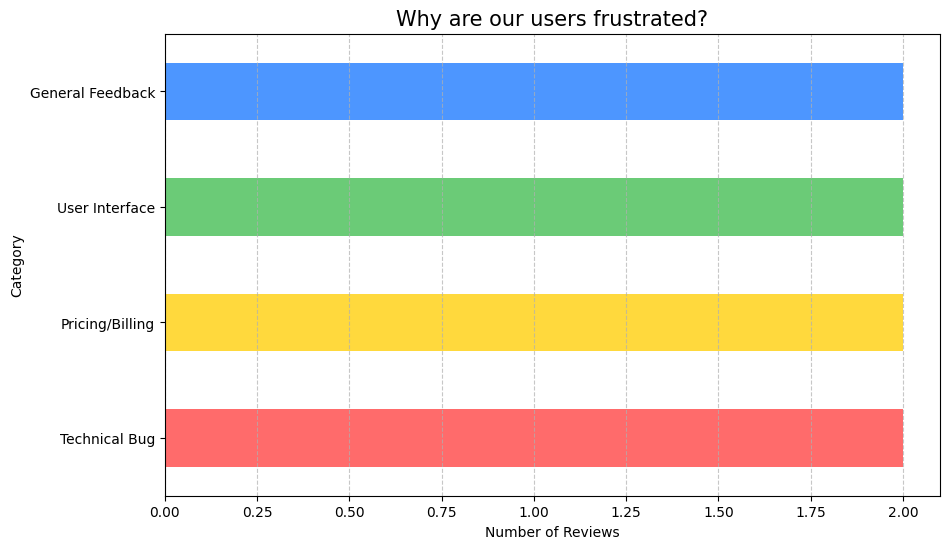


ACTIONABLE TO-DO LIST
[TECHNICAL BUG] -> The app crashes every time I try to save my work. Fix it!
[PRICING/BILLING] -> Why is the subscription $20? It's way too expensive.
[USER INTERFACE] -> I can't find the logout button. The interface is so confusing.
[PRICING/BILLING] -> I love the features, but the monthly price is too high.
[USER INTERFACE] -> The new layout is a mess, I liked the old UI better.
[TECHNICAL BUG] -> Error 505 popped up when I tried to sync my data.

Task Complete: All reviews have been sorted.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# =================================================================
# 1. LOAD THE DATA
# =================================================================
# In a real scenario, you'd use: df = pd.read_csv('reviews.csv')
# For now, let's use a "human-made" list of common frustrations.

raw_data = {
    'user_review': [
        "The app crashes every time I try to save my work. Fix it!",
        "Why is the subscription $20? It's way too expensive.",
        "I can't find the logout button. The interface is so confusing.",
        "It keeps freezing on the loading screen. Waste of time.",
        "I love the features, but the monthly price is too high.",
        "The new layout is a mess, I liked the old UI better.",
        "Works great, no issues so far!",
        "Error 505 popped up when I tried to sync my data."
    ],
    'star_rating': [1, 2, 2, 1, 3, 2, 5, 1]
}

df = pd.DataFrame(raw_data)

# =================================================================
# 2. THE "BRAINS" OF THE TOOL (Categorization)
# =================================================================
def find_the_problem(text):
    """
    This function acts like a filter. It looks for specific 'red flag'
    words to sort the reviews into buckets.
    """
    review = str(text).lower() # standardizing to lowercase

    # Check for Tech Bugs
    if any(word in review for word in ['crash', 'freeze', 'fix', 'error', 'bug', 'broken']):
        return "Technical Bug"

    # Check for Money issues
    elif any(word in review for word in ['price', 'expensive', 'cost', 'subscription', 'pay']):
        return "Pricing/Billing"

    # Check for Confusion/Design issues
    elif any(word in review for word in ['confusing', 'ui', 'ux', 'layout', 'navigation', 'button']):
        return "User Interface"

    # If it doesn't match the above, it's likely just general talk
    else:
        return "General Feedback"

# Create a new column to store our findings
df['Category'] = df['user_review'].apply(find_the_problem)

# =================================================================
# 3. CREATING THE "MANAGER'S REPORT" (Visualization)
# =================================================================
print("--- SUMMARY REPORT ---")
category_totals = df['Category'].value_counts()

# Let's make a clean chart so the boss can see the biggest problem at a glance
plt.figure(figsize=(10, 6))
category_totals.plot(kind='barh', color=['#FF6B6B', '#FFD93D', '#6BCB77', '#4D96FF'])
plt.title('Why are our users frustrated?', fontsize=15)
plt.xlabel('Number of Reviews')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# =================================================================
# 4. ACTIONABLE LIST FOR THE TEAM
# =================================================================
print("\n" + "="*30)
print("ACTIONABLE TO-DO LIST")
print("="*30)

# Filter out the 'General Feedback' and only show the problems
problems = df[df['Category'] != "General Feedback"]

for index, row in problems.iterrows():
    print(f"[{row['Category'].upper()}] -> {row['user_review']}")

print("\nTask Complete: All reviews have been sorted.")